# 10 — Composite v2: Two-Channel (Level + Deferral) under Physical Procurement Accounting

**Goal:** test whether the forward-change amplifiers (S/U, ENSO, flowering) — which notebook
06 proved carry real directional information (+3.56% of budget under deferral accounting,
partials ≈ +0.42 given L1) that architecture B could not convert into level savings — earn
their keep when given their own channel and judged on a **physically consistent objective**.

**Architecture (C, two-channel):**

    w_t = clip( 1 + λ_L·ℓ_t + λ_D·d_t , 0.25, 1.75 )

    ℓ_t = 2·L1_t − 1                    # level channel — unchanged, validated (NB01)
    d_t = Σ_a w_a·c_a,t                 # deferral channel: {stu, enso, flow}, renormalised
                                        #   over components available at t

λ_L is **fixed at 0.75** (the suite's gain; λ_D = 0 then reproduces the 06 α=0 arm exactly,
so "L1-alone" nests inside this notebook and every comparison is apples-to-apples). Only the
deferral side is optimised.

**Cut from 06, each with cause:** COT is out of the deferral basket — a 6-month,
sign-unstable momentum signal (positive in only 45% of rolling windows) has no business in a
12–23-month forward channel, and its 06 ablation was exactly 0.00. Vol damping (δ) and
seasonality (γ) are out entirely — chosen δ=1.0, γ=0 in all 24 arm-years of 06: dead degrees
of freedom. The grid shrinks from ~2,400 to ~96 candidates; less machinery, less multiple
testing.

## The objective: an inventory-constrained procurement simulation

The suite's canonical metric (signal-weighted average price) and NB08's deferral accounting
are both *partial* views, and 06 showed they can disagree by design. This notebook replaces
them with the number a roaster actually minimises: **total cost per unit consumed**, from a
simulation with fixed consumption of 1 unit/month, an inventory buffer, a storage cap, and
carry charged on inventory value:

    p_t = clip( w_t , max(0, 1 − i_{t−1}) , 1 + I_MAX − i_{t−1} )     # feasibility
    i_t = i_{t−1} + p_t − 1                                           # ∈ [0, I_MAX]
    cash_t = p_t·P_t + (CARRY/12)·max(i_t − I0, 0)·P_t
    naive: p ≡ 1, i ≡ I0 (zero excess carry).  Terminal inventory difference marked
    to market at P_T.

Why this is the right judge, from first principles: (1) it **unifies level and deferral** —
buying cheap months (level) and buying ahead of rises (deferral) both reduce the same cost
line, with carry netted automatically, so no more metric arbitration; (2) it **disciplines
both channels** — 06's L1-alone +11.16% pooled implicitly assumed free unbounded storage
(holding w=0.25 through an 18-month rally silently consumes ~13 months of inventory never
bought). Expect L1's headline to shrink here; that is realism arriving, not regression;
(3) deferral needs no explicit horizon pairing (NB08's t→t+h): the inventory path *is* the
deferral, with constraints binding where they physically would.

Two modelling notes, disclosed up front. **Carry is charged only on inventory above the
baseline buffer** — `(CARRY/12)·max(i_t − I0, 0)·P_t`, naive paying zero: the base buffer is
shared infrastructure both policies run, so the deferral channel is taxed on exactly the
*extra* it chooses to hold, and running lean earns nothing (validation showed that charging
carry on absolute inventory lets any strategy harvest fake "alpha" vs the naive by simply
de-stocking — an artifact unrelated to price forecasting that does not cancel between arms,
because the optimiser can adapt its inventory posture to the carry rate while L1 cannot).
And the simulation ignores transaction costs, lot sizing, and market impact — adequate at
roaster scale, stated for completeness.

**Gates (pre-registered; evaluated at YOUR `CARRY_ANNUAL` / `I_MAX` — set them in §0):**

| Gate | Statement |
|---|---|
| **D1** | nested-opt simulated saving over the stitched OOS path (2013–2024) ≥ **L1-alone** at the configured (carry, I_MAX) |
| **D2** | worst calendar year: opt ≥ L1-alone − 1.0 pp (per-year cash, % of that year's naive spend) |
| **D3** | stress: D1 still holds at carry = 6%/yr with I_MAX = 2 (re-optimised) — the edge must not require the friendliest parameters |

Plus the **carry frontier**: nested walk-forward re-run at each carry in 0–12%/yr, reporting
the rate at which the deferral channel dies. A failed gate is a valid outcome — 06's was.

**Priors going in** (written before results): 06's diagnostic measured ≈ +3.56% gross
deferral value on |Δw| ≈ 0.13; at the suite's documented carry prior (0.5–1%/yr, NB08 §6)
the carry drag on that shift is ≈ 0.1–0.2%, so the channel plausibly nets +2–3% *if* the
inventory constraints don't bind it away and the nested optimiser can find it with 3–14
training years. Everything inherited from 06 §2 (as-of rules, PSD vintage caveat, KC splice)
applies unchanged.

## 0. Setup

`CARRY_ANNUAL` and `I_MAX` are the two numbers that make the gates *yours* — the defaults
are the suite's documented prior (NB08 §6) and a moderate warehouse, and the §6 sweeps show
every alternative, but D1–D3 are judged at what is set here.

In [1]:
import os
import sys
import itertools
import warnings

sys.path.insert(0, os.path.abspath('../..'))   # repo root, as in notebooks 01-06
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

# ── Business parameters — SET THESE TO YOUR REALITY ────────────────────────
CARRY_ANNUAL = 0.01   # ← all-in annual carry on inventory value (storage + insurance +
                      #   financing). Default 1%/yr = suite prior (NB08 §6: "0.5–1%/yr").
                      #   If your treasury charges WACC on tied-up cash, use that figure.
I_MAX        = 3.0    # ← storage cap, months of consumption you can physically hold
I0           = I_MAX / 2.0   # baseline buffer both naive and strategies start with

# ── Signal construction (inherited from 06 verbatim where shared) ──────────
L1_WINDOW_M  = 24
LAMBDA_L     = 0.75            # fixed level gain — λ_D=0 reproduces the 06 α=0 arm
W_LO, W_HI   = 0.25, 1.75
ENSO_LAG_M   = 3
FLOWER_SCALE = 1.5
DEF_AMPS     = ['stu', 'enso', 'flow']   # deferral basket (COT excluded — see header)

# ── Windows ─────────────────────────────────────────────────────────────────
CORE_START, CORE_END = '2010-01-01', '2024-12-31'
WF_YEARS     = list(range(2013, 2025))
MIN_TRAIN_Y  = 3

# ── Optimiser grid (lean — see header) ─────────────────────────────────────
GRID_LAMBDA_D = [0.0, 0.15, 0.30, 0.45, 0.60]
GRID_WLEVEL   = [0, 1, 2]
OPT_MARGIN    = 0.10           # pp of simulated training saving vs the λ_D=0 baseline

# ── §6 sweeps ───────────────────────────────────────────────────────────────
CARRY_SWEEP = [0.00, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
IMAX_SWEEP  = [1.0, 2.0, 3.0, 6.0]

ZONES = [(1.50, 'STRONG BUY'), (1.15, 'BUY'), (0.85, 'NEUTRAL'),
         (0.50, 'REDUCE'), (-np.inf, 'AVOID')]

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)
plt.rcParams['figure.dpi'] = 120

def zone_of(w):
    for lo, name in ZONES:
        if w >= lo:
            return name
    return 'AVOID'

print(f'carry {CARRY_ANNUAL:.1%}/yr | I_MAX {I_MAX:.0f}m | I0 {I0:.1f}m | '
      f'λ_L {LAMBDA_L} fixed | λ_D grid {GRID_LAMBDA_D}')
print(f'Deferral basket {DEF_AMPS} | grid ≈ {len(GRID_LAMBDA_D)-1} λ_D × '
      f'{len(GRID_WLEVEL)**len(DEF_AMPS)-1} weight combos (+ λ_D=0 baseline)')

carry 1.0%/yr | I_MAX 3m | I0 1.5m | λ_L 0.75 fixed | λ_D grid [0.0, 0.15, 0.3, 0.45, 0.6]
Deferral basket ['stu', 'enso', 'flow'] | grid ≈ 4 λ_D × 26 weight combos (+ λ_D=0 baseline)


## 1. Load Inputs

Same reference CSVs as 06 minus COT — **v2 needs no network access at all**. Adds a
freshness check: 06's live run showed the ENSO channel silently renormalising away because
`oni_monthly.csv` ended four months behind the price series; that is now a loud warning
pointing at the notebook to rerun.

In [2]:
from domains.coffee.sources.usda_psd import stu_risk_score  # noqa: E402
from domains.coffee.sources.noaa_enso import enso_risk_score  # noqa: E402

REQUIRED_CSVS = {
    'kc':      ('data/ice_kc_monthly.csv',       'notebook 01'),
    'oni':     ('data/oni_monthly.csv',           'notebook 02'),
    'stu_ann': ('data/stu_annual.csv',            'notebook 04'),
    'chirps':  ('data/chirps_minas_monthly.csv',  'notebook 05'),
    'wb_rob':  ('data/wb_robusta_monthly.csv',    'notebook 07'),
}
raw = {}
for key, (path, src_nb) in REQUIRED_CSVS.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f'{path} missing — run {src_nb} first to generate it.')
    raw[key] = pd.read_csv(path, parse_dates=['date'], index_col='date').sort_index()

print(f"{'input':10s} {'first':>12s} {'last':>12s} {'rows':>6s}")
print('─' * 46)
for key, df_ in raw.items():
    print(f"{key:10s} {str(df_.index[0].date()):>12s} {str(df_.index[-1].date()):>12s} "
          f"{len(df_):>6d}")

# ── Freshness warnings (the 06 lesson) ──────────────────────────────────────
kc_last = raw['kc'].index[-1]
lag_oni = (kc_last.year - raw['oni'].index[-1].year) * 12 \
          + (kc_last.month - raw['oni'].index[-1].month)
if lag_oni > ENSO_LAG_M + 1:
    print(f'\n⚠ ONI ends {lag_oni} months behind KC — the ENSO channel will renormalise '
          f'away for the most recent months. Rerun notebook 02 to refresh.')
last_nov = raw['chirps'][raw['chirps'].index.month == 11].index[-1]
if (kc_last.year - last_nov.year) > 1:
    print(f'⚠ Last CHIRPS November is {last_nov.date()} — flowering signal may be stale. '
          f'Rerun notebook 05.')

input             first         last   rows
──────────────────────────────────────────────
kc           2008-01-31   2026-05-31    221
oni          1980-01-31   2025-12-31    552
stu_ann      2000-12-31   2025-12-31     26
chirps       2008-01-31   2025-12-31    216
wb_rob       2000-01-31   2025-12-31    312

⚠ ONI ends 5 months behind KC — the ENSO channel will renormalise away for the most recent months. Rerun notebook 02 to refresh.


## 2. As-Of Component Construction

Verbatim from 06 §2 for the shared pieces (L1, S/U, ENSO, flowering; STRICT and STANDARD
as-of modes; NaN renormalisation) — see that notebook for the lag derivations. COT and the
RV regime are not built (cut). The SPI helper again prefers the promoted
`climate_features.py` import with a local fallback.

In [3]:
try:
    from domains.coffee.features.climate_features import spi_from_gamma
    print('spi_from_gamma imported from climate_features (promotion done).')
except ImportError:
    def spi_from_gamma(value, fit_values):
        """Standardized Precipitation Index via gamma fit with zero-precip correction.
        Verbatim from NB05 §3 / NB06 §2 — promote to climate_features.py when convenient."""
        fit = np.asarray(fit_values, dtype=float)
        fit = fit[~np.isnan(fit)]
        pos = fit[fit > 0]
        q = float((fit <= 0).sum()) / len(fit)
        if len(pos) < 4 or pos.std() == 0:
            mu, sd = fit.mean(), (fit.std(ddof=0) or 1.0)
            return float((value - mu) / sd)
        a, loc, scale = stats.gamma.fit(pos, floc=0)
        cdf = q + (1 - q) * stats.gamma.cdf(value, a, loc=loc, scale=scale)
        return float(stats.norm.ppf(np.clip(cdf, 1e-6, 1 - 1e-6)))
    print('spi_from_gamma defined locally (climate_features.py not found).')


def l1_buy(settle, n=L1_WINDOW_M):
    """Continuous L1 buy signal: 1 − rolling price position (NB01 §4b construction)."""
    lo = settle.rolling(n, min_periods=int(n * 0.7)).min()
    hi = settle.rolling(n, min_periods=int(n * 0.7)).max()
    spread = (hi - lo)
    pos = ((settle - lo) / spread.where(spread > 0)).clip(0, 1)
    return (1.0 - pos).rename('l1_buy')


def flowering_deficit_by_year(chirps, strict):
    """Sep–Nov SPI-3 deficit per crop year (STRICT: expanding refit, ≥8 prior yrs)."""
    acc3 = chirps['precip'].rolling(3).sum()
    nov = acc3[acc3.index.month == 11]
    nov.index = nov.index.year
    if strict:
        vals = {}
        for y, v in nov.items():
            prior = nov[nov.index < y].values
            vals[y] = spi_from_gamma(v, prior) if (np.isfinite(v) and len(prior) >= 8) else np.nan
        spi3_nov = pd.Series(vals)
    else:
        s = chirps['spi3'][chirps.index.month == 11]
        s.index = s.index.year
        spi3_nov = s
    return np.maximum(0.0, -spi3_nov)


def build_components(price_df, strict, amps):
    """ME decision frame: settle, l1_buy, and the requested c_* columns."""
    settle = price_df['settle'].resample('ME').last().rename('settle')
    f = settle.to_frame()
    f['l1_buy'] = l1_buy(settle)
    if 'stu' in amps:
        stu_m = raw['stu_ann']['stu'].resample('ME').ffill().reindex(f.index).ffill()
        f['c_stu'] = 2.0 * stu_m.map(stu_risk_score) - 1.0
    if 'enso' in amps:
        lag = ENSO_LAG_M + (1 if strict else 0)
        oni_sig = raw['oni']['oni_anom'].rolling(3, min_periods=2).mean().shift(lag)
        f['c_enso'] = 2.0 * oni_sig.reindex(f.index).map(
            lambda v: enso_risk_score(v) if pd.notna(v) else np.nan) - 1.0
    if 'flow' in amps:
        deficit = flowering_deficit_by_year(raw['chirps'], strict)
        yrs = f.index.year - (f.index.month <= 11)
        months = pd.Series(deficit.reindex(yrs).values, index=f.index, dtype=float)
        f['c_flow'] = np.minimum(months / FLOWER_SCALE, 1.0)
    return f


frames = {'STRICT': build_components(raw['kc'], True, DEF_AMPS),
          'STANDARD': build_components(raw['kc'], False, DEF_AMPS)}

print('\nComponent coverage (first valid month):')
for mode, f in frames.items():
    firsts = {c: (str(f[c].first_valid_index().date())
                  if f[c].first_valid_index() is not None else '—')
              for c in f.columns if c != 'settle'}
    print(f'  {mode:9s}', firsts)

spi_from_gamma defined locally (climate_features.py not found).

Component coverage (first valid month):
  STRICT    {'l1_buy': '2009-04-30', 'c_stu': '2008-01-31', 'c_enso': '2008-01-31', 'c_flow': '2016-12-31'}
  STANDARD  {'l1_buy': '2009-04-30', 'c_stu': '2008-01-31', 'c_enso': '2008-01-31', 'c_flow': '2008-12-31'}


## 3. Two-Channel Formula

**In:** the component frame + θ = (λ_D, {w_a}). **Out:** desired weight `w_t` and additive
contributions (`level`, one per deferral amp) summing to `w_t − 1` pre-clip.

The structural difference from 06: the deferral term does **not** carry a `|core|` factor —
the amplifiers can front-load at price highs (what they were right about in 2021 and
2024–25) and can lean against a cheap price if fundamentals are bearish. Whether that
freedom nets money after carry is exactly what the simulation judges.

In [4]:
def composite_w_v2(df, lambda_d, wts, amps=DEF_AMPS, lambda_l=LAMBDA_L,
                   w_lo=W_LO, w_hi=W_HI, want_contrib=False):
    """w = clip(1 + λ_L·ℓ + λ_D·d).  Missing amplifiers renormalise (as 06 §2)."""
    core = 2.0 * df['l1_buy'] - 1.0
    used = {a: w for a, w in wts.items() if a in amps and w > 0}
    if used and lambda_d > 0:
        num = pd.Series(0.0, index=df.index)
        den = pd.Series(0.0, index=df.index)
        for a, wa in used.items():
            c = df[f'c_{a}']
            ok = c.notna()
            num = num + wa * c.fillna(0.0) * ok
            den = den + wa * ok
        d = (num / den.replace(0, np.nan)).fillna(0.0)
    else:
        d = pd.Series(0.0, index=df.index)
        den = pd.Series(np.nan, index=df.index)

    w = (1.0 + lambda_l * core + lambda_d * d).clip(w_lo, w_hi)
    w[core.isna()] = np.nan
    if not want_contrib:
        return w
    contrib = pd.DataFrame({'level_L1': lambda_l * core}, index=df.index)
    for a, wa in used.items():
        c = df[f'c_{a}']
        share = (wa * c.fillna(0.0) * c.notna()) / den.replace(0, np.nan)
        contrib[f'defer_{a}'] = lambda_d * share.fillna(0.0)
    return w, contrib


w_demo = composite_w_v2(frames['STRICT'], 0.30, dict.fromkeys(DEF_AMPS, 1))
print(f'Demo (λ_D=0.30, equal weights): {w_demo.notna().sum()} valid months, '
      f'range [{w_demo.min():.2f}, {w_demo.max():.2f}]')
print('Zone counts:', w_demo.dropna().map(zone_of).value_counts().to_dict())

Demo (λ_D=0.30, equal weights): 206 valid months, range [0.25, 1.75]
Zone counts: {'AVOID': 53, 'STRONG BUY': 51, 'BUY': 49, 'REDUCE': 27, 'NEUTRAL': 26}


## 4. The Procurement Simulator + Unit Tests

**In:** a desired-weight path, prices, (carry, I_MAX, I0). **Out:** saving % of naive total
cost, plus the feasible purchase path, inventory path, clip statistics, and a per-year
decomposition marking the **excess inventory position at both ends of each year**
(`(i_end−I0)·P_end − (i_start−I0)·P_prev_end`) — raw cash flows per year are dominated by
buffer builds and draws (validation showed ±20 pp swings that were pure inventory phase),
while open/close marks score each year's true economics: holding cheap stock through a spike
is that year's paper gain, not a phantom loss. The marks telescope, so per-year figures
decompose the headline **exactly in cash terms** (percentages use per-year denominators).

The simulator is self-verified by four unit tests before anything downstream trusts it:
naive-vs-naive must be exactly zero; a constant-price world bounds |saving| by the carry
envelope (a strategy can only win/lose carry there, never price); inventory bounds must hold
under adversarial random weights; and a deterministic front-loading toy (flat 100 → flat
130) must show positive saving at zero carry that decays monotonically as carry rises.

In [5]:
def procurement_sim(w, settle, carry_annual=CARRY_ANNUAL, i_max=I_MAX, i0=None,
                    detail=False):
    """Inventory-constrained procurement simulation (see header derivation).
    Evaluates over the contiguous span where both w and settle are available."""
    if i0 is None:
        i0 = i_max / 2.0
    s = pd.concat([w.rename('w'), settle.rename('p')], axis=1).dropna()
    if len(s) < 12:
        return np.nan if not detail else None
    wv, pv = s['w'].to_numpy(float), s['p'].to_numpy(float)
    n = len(s)
    mc = carry_annual / 12.0

    p_buy = np.empty(n)
    inv = np.empty(n)
    prev = i0
    clipped = 0
    for k in range(n):
        lo = max(0.0, 1.0 - prev)
        hi = 1.0 + i_max - prev
        p_buy[k] = min(max(wv[k], lo), hi)
        if p_buy[k] != wv[k]:
            clipped += 1
        prev = prev + p_buy[k] - 1.0
        inv[k] = prev

    excess = np.maximum(inv - i0, 0.0)
    cash_sig = p_buy * pv + mc * excess * pv
    cash_nai = 1.0 * pv                      # naive holds i0 → zero excess carry
    total_sig = cash_sig.sum() - (inv[-1] - i0) * pv[-1]      # terminal mark-to-market
    total_nai = cash_nai.sum()
    saving = (total_nai - total_sig) / total_nai * 100.0
    if not detail:
        return float(saving)

    yr = s.index.year.to_numpy()
    per_year = {}
    i_start, p_prev_end = i0, None
    for y in np.unique(yr):
        m = yr == y
        i_end, p_end = inv[m][-1], pv[m][-1]
        open_mark = (i_start - i0) * (p_prev_end if p_prev_end is not None else 0.0)
        close_mark = (i_end - i0) * p_end
        per_year[int(y)] = float(
            (cash_nai[m].sum() - cash_sig[m].sum() + close_mark - open_mark)
            / cash_nai[m].sum() * 100.0)
        i_start, p_prev_end = i_end, p_end
    return {'saving': float(saving), 'p_buy': pd.Series(p_buy, index=s.index),
            'inventory': pd.Series(inv, index=s.index), 'per_year': per_year,
            'clip_share': clipped / n, 'span': (s.index[0], s.index[-1])}


# ── Unit tests ──────────────────────────────────────────────────────────────
_idx = pd.date_range('2015-01-31', periods=48, freq='ME')
_flat = pd.Series(100.0, index=_idx)
_rng = np.random.default_rng(0)

t1 = procurement_sim(pd.Series(1.0, index=_idx), _flat, 0.05, 3.0)
ok1 = abs(t1) < 1e-9

_wrand = pd.Series(_rng.uniform(W_LO, W_HI, len(_idx)), index=_idx)
t2 = procurement_sim(_wrand, _flat, 0.05, 3.0)
bound2 = 0.05 / 12 * (3.0 - I0) * 100 * 1.05
ok2 = (t2 <= 1e-9) and (t2 >= -bound2)

d2 = procurement_sim(_wrand, _flat, 0.05, 3.0, detail=True)
ok3 = (d2['inventory'].min() >= -1e-9) and (d2['inventory'].max() <= 3.0 + 1e-9)

_step = pd.Series([100.0] * 24 + [130.0] * 24, index=_idx)
# Front-load then hold: buys extra at 100, consumed at 130 — positive at zero carry,
# taxed away monotonically as carry on the excess holdings rises.
_wfront = pd.Series([W_HI] * 24 + [1.0] * 24, index=_idx)
t4 = [procurement_sim(_wfront, _step, c, 3.0) for c in (0.0, 0.10, 0.30, 0.60)]
ok4 = (t4[0] > 0) and all(t4[i] > t4[i + 1] for i in range(len(t4) - 1))

for name, ok, msg in [
    ('T1 naive-vs-naive == 0', ok1, f'{t1:+.2e}%'),
    ('T2 constant price ⇒ saving ≤ 0 (only excess carry can differ)', ok2,
     f'{t2:+.3f}% (floor −{bound2:.3f}%)'),
    ('T3 inventory bounds respected', ok3,
     f'[{d2["inventory"].min():.3f}, {d2["inventory"].max():.3f}]'),
    ('T4 front-load: +ve at 0 carry, monotone ↓ in carry', ok4,
     ' → '.join(f'{v:+.2f}%' for v in t4)),
]:
    print(f'{"PASS ✓" if ok else "FAIL ✗"}  {name}: {msg}')
assert ok1 and ok2 and ok3 and ok4, 'simulator unit tests failed — do not trust results'

PASS ✓  T1 naive-vs-naive == 0: +0.00e+00%
PASS ✓  T2 constant price ⇒ saving ≤ 0 (only excess carry can differ): -0.292% (floor −0.656%)
PASS ✓  T3 inventory bounds respected: [0.000, 3.000]
PASS ✓  T4 front-load: +ve at 0 carry, monotone ↓ in carry: +0.82% → -0.42% → -2.90% → -6.62%


## 5. Nested Walk-Forward Optimisation

Protocol as 06 §5, with the simulation as the objective: for each test year *y*, the grid
θ = (λ_D, {w_a}) is scored by **simulated saving over the training span** (2010 → Dec *y−1*,
inventory dynamics included) at the configured (carry, I_MAX); the do-no-harm prior requires
a candidate to beat the λ_D = 0 baseline by `OPT_MARGIN` (0.10 pp) or the optimiser abstains
to pure L1 for that year. Ties break to smaller λ_D, then fewer amplifiers. The chosen θ_y
produces year *y*'s out-of-sample weights; the stitched OOS path is then simulated **once,
end-to-end** (inventory carries across year boundaries — per-year re-initialisation would
throw away exactly the cross-year positioning the channel exists for).

Arms: **L1-alone** (λ_D = 0 — bit-identical to 06's α = 0 arm), **Equal-weight fixed**
(λ_D = 0.30, equal basket, never re-fit), **Nested-opt**. Plus the full-period in-sample
ceiling, labelled as the inflated upper bound it is. The legacy pooled metric is reported
one line for cross-suite continuity with 06.

In [6]:
def weight_grid(amps):
    seen, out = set(), []
    for combo in itertools.product(GRID_WLEVEL, repeat=len(amps)):
        if sum(combo) == 0:
            continue
        tot = sum(combo)
        key = tuple(round(c / tot, 3) for c in combo)
        if key in seen:
            continue
        seen.add(key)
        out.append(dict(zip(amps, combo)))
    return out


def theta_grid_v2(amps):
    yield dict(lambda_d=0.0, wts=dict.fromkeys(amps, 0))
    for ld in GRID_LAMBDA_D:
        if ld == 0.0:
            continue
        for wts in weight_grid(amps):
            yield dict(lambda_d=ld, wts=wts)


def score_theta_v2(df, theta, carry, i_max, amps):
    w = composite_w_v2(df, theta['lambda_d'], theta['wts'], amps=amps)
    return procurement_sim(w, df['settle'], carry, i_max)


def nested_walkforward_v2(df, amps, arm='opt', carry=CARRY_ANNUAL, i_max=I_MAX,
                          test_years=WF_YEARS):
    """One arm of the nested walk-forward under the simulation objective.
    Out: (per-year θ DataFrame, stitched OOS desired-weight Series)."""
    rows, w_parts = [], []
    for y in test_years:
        train = df[(df.index >= CORE_START) & (df.index.year < y)]
        n_train_y = len({d.year for d in train.index
                         if train.loc[train.index.year == d.year, 'l1_buy']
                            .notna().sum() >= 10})
        if n_train_y < MIN_TRAIN_Y:
            continue

        if arm == 'l1':
            theta = dict(lambda_d=0.0, wts=dict.fromkeys(amps, 0))
        elif arm == 'eq':
            theta = dict(lambda_d=0.30, wts=dict.fromkeys(amps, 1))
        else:
            base = score_theta_v2(train, dict(lambda_d=0.0,
                                              wts=dict.fromkeys(amps, 0)),
                                  carry, i_max, amps)
            cands = []
            for th in theta_grid_v2(amps):
                sv = score_theta_v2(train, th, carry, i_max, amps)
                if np.isnan(sv):
                    continue
                if th['lambda_d'] > 0 and sv < base + OPT_MARGIN:
                    continue
                n_amps = sum(1 for v in th['wts'].values() if v > 0)
                cands.append(((-round(sv, 6), th['lambda_d'], n_amps), th))
            theta = min(cands, key=lambda kv: kv[0])[1] if cands else \
                dict(lambda_d=0.0, wts=dict.fromkeys(amps, 0))

        w_full = composite_w_v2(df, theta['lambda_d'], theta['wts'], amps=amps)
        rows.append({'year': y, 'lambda_d': theta['lambda_d'],
                     **{f'w_{a}': theta['wts'].get(a, 0) for a in amps}})
        w_parts.append(w_full[w_full.index.year == y])
    res = pd.DataFrame(rows).set_index('year')
    w_oos = pd.concat(w_parts).sort_index() if w_parts else pd.Series(dtype=float)
    return res, w_oos


def pooled_saving_legacy(w, settle):
    """06's pooled level metric — reported for cross-suite continuity only."""
    ps = settle.reindex(w.index)
    m = w.notna() & ps.notna()
    if m.sum() < 12 or w[m].sum() <= 0:
        return np.nan
    return float((ps[m].mean() - (w[m] * ps[m]).sum() / w[m].sum())
                 / ps[m].mean() * 100.0)


results, w_paths, sims = {}, {}, {}
for mode in ['STRICT', 'STANDARD']:
    for arm, label in [('l1', 'L1-alone'), ('eq', 'Equal-weight'), ('opt', 'Nested-opt')]:
        res, w_oos = nested_walkforward_v2(frames[mode], DEF_AMPS, arm=arm)
        results[(mode, label)] = res
        w_paths[(mode, label)] = w_oos
        sims[(mode, label)] = procurement_sim(w_oos, frames[mode]['settle'],
                                              CARRY_ANNUAL, I_MAX, detail=True)

# Full-period in-sample ceiling (STRICT)
train_all = frames['STRICT'][(frames['STRICT'].index >= CORE_START)
                             & (frames['STRICT'].index <= CORE_END)]
ceil_best, theta_ceiling = -np.inf, None
for th in theta_grid_v2(DEF_AMPS):
    sv = score_theta_v2(train_all, th, CARRY_ANNUAL, I_MAX, DEF_AMPS)
    if not np.isnan(sv) and sv > ceil_best:
        ceil_best, theta_ceiling = sv, th

# ── Report ──────────────────────────────────────────────────────────────────
print(f'Per-year saving (% of that year\'s naive spend; open/close MTM marks on excess '
      f'inventory), carry {CARRY_ANNUAL:.1%}, I_MAX {I_MAX:.0f}m:')
tbl = pd.DataFrame({f'{m[:4]}·{l}': pd.Series(sims[(m, l)]['per_year'])
                    for m in ['STRICT', 'STANDARD']
                    for l in ['L1-alone', 'Equal-weight', 'Nested-opt']})
print(pd.concat([tbl, tbl.min().rename('WORST').to_frame().T]).round(2).to_string())

print('\nHeadline simulated saving over the stitched 2013–2024 OOS path:')
for m in ['STRICT', 'STANDARD']:
    parts = [f"{l} {sims[(m, l)]['saving']:+.2f}%"
             for l in ['L1-alone', 'Equal-weight', 'Nested-opt']]
    print(f'  {m:9s} ' + ' | '.join(parts))
    cs = {l: f"{sims[(m, l)]['clip_share']:.0%}"
          for l in ['L1-alone', 'Nested-opt']}
    print(f'            (feasibility-clipped months: {cs})')

print(f"\nFull-period IN-SAMPLE ceiling (STRICT): {ceil_best:+.2f}%  "
      f"θ = λ_D {theta_ceiling['lambda_d']} w{theta_ceiling['wts']}")
print('  ↑ upper bound only — the gap to Nested-opt is the multiple-testing tax.')

print('\nLegacy pooled level metric (06-comparable, continuity only):')
for l in ['L1-alone', 'Nested-opt']:
    print(f"  {l:12s} {pooled_saving_legacy(w_paths[('STRICT', l)], frames['STRICT']['settle']):+.2f}%")

Per-year saving (% of that year's naive spend; open/close MTM marks on excess inventory), carry 1.0%, I_MAX 3m:
       STRI·L1-alone  STRI·Equal-weight  STRI·Nested-opt  STAN·L1-alone  STAN·Equal-weight  STAN·Nested-opt
2013           -3.54              -3.55            -3.58          -3.54              -3.55            -3.58
2014            6.45               6.29             6.29           6.45               6.29             6.29
2015            3.62               3.74             2.97           3.62               3.58             2.84
2016            1.48               1.22             0.83           1.48               1.32             1.10
2017           -0.27              -0.46             0.03          -0.27              -0.23             0.38
2018           -2.84              -2.84            -2.84          -2.84              -2.84            -2.84
2019            2.87               2.92             3.10           2.87               2.91             3.05
2020            2.94    

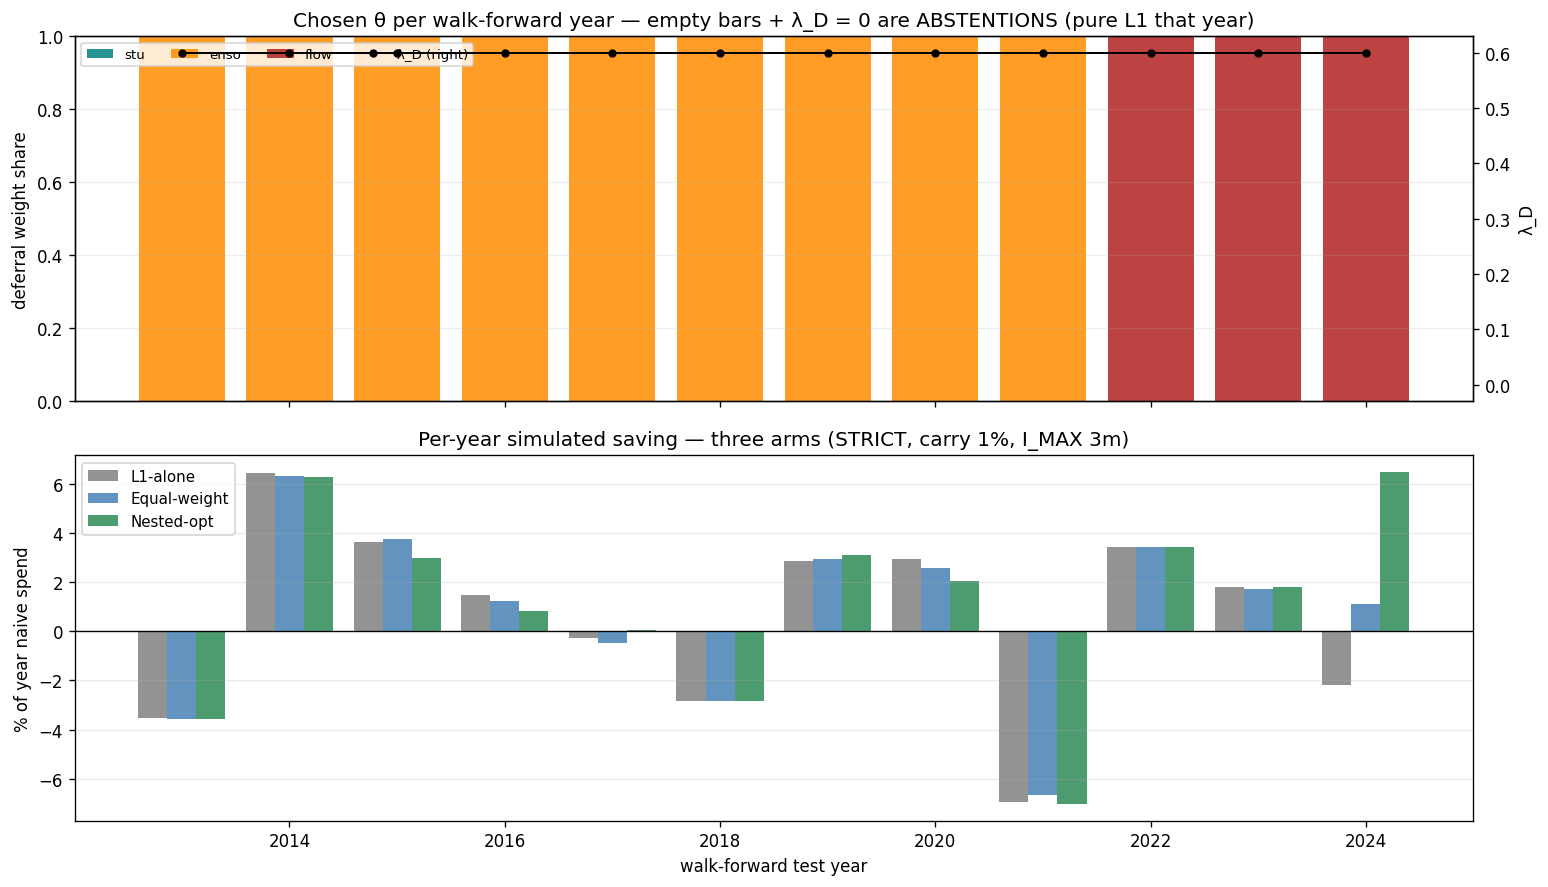

Saved: data/10_wf_arms.png


In [7]:
# ── θ-path + per-year chart (STRICT) ────────────────────────────────────────
res_opt = results[('STRICT', 'Nested-opt')]
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

ax = axes[0]
years = res_opt.index.values
bottom = np.zeros(len(res_opt))
colors_a = {'stu': 'teal', 'enso': 'darkorange', 'flow': 'firebrick'}
wsum = res_opt[[f'w_{a}' for a in DEF_AMPS]].sum(axis=1).replace(0, np.nan)
for a in DEF_AMPS:
    share = (res_opt[f'w_{a}'] / wsum).fillna(0.0).values
    ax.bar(years, share, bottom=bottom, color=colors_a[a], alpha=0.85, label=a)
    bottom += share
ax2 = ax.twinx()
ax2.plot(years, res_opt['lambda_d'], color='black', marker='o', ms=4, lw=1.2,
         label='λ_D (right)')
ax2.set_ylim(-0.03, max(GRID_LAMBDA_D) + 0.03)
ax2.set_ylabel('λ_D')
ax.set_ylabel('deferral weight share')
ax.set_title('Chosen θ per walk-forward year — empty bars + λ_D = 0 are ABSTENTIONS '
             '(pure L1 that year)')
h1, l1_ = ax.get_legend_handles_labels()
h2, l2_ = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1_ + l2_, fontsize=8, ncol=4, loc='upper left')
ax.grid(alpha=0.2, axis='y')

ax = axes[1]
width = 0.27
py = {l: pd.Series(sims[('STRICT', l)]['per_year']) for l in
      ['L1-alone', 'Equal-weight', 'Nested-opt']}
for i, (label, color) in enumerate([('L1-alone', 'gray'), ('Equal-weight', 'steelblue'),
                                    ('Nested-opt', 'seagreen')]):
    s = py[label]
    ax.bar(s.index + (i - 1) * width, s.values, width, color=color, alpha=0.85,
           label=label)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('% of year naive spend')
ax.set_xlabel('walk-forward test year')
ax.set_title(f'Per-year simulated saving — three arms (STRICT, carry {CARRY_ANNUAL:.0%}, '
             f'I_MAX {I_MAX:.0f}m)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('data/10_wf_arms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/10_wf_arms.png')

## 6. Gates, the Carry Frontier, and the Current Reading

D1–D3 as pre-registered. The frontier is the honest version: the nested optimisation is
**re-run from scratch at each carry rate** (θ trained at the same carry it is judged at —
sweeping evaluation carry under a fixed θ would flatter whichever side the training rate
favoured), while the L1-alone path is carry-independent by construction and only re-priced.
Same treatment for the I_MAX sweep. D3 re-optimises at the stress point (6%/yr, 2 months).

In [8]:
s_opt = sims[('STRICT', 'Nested-opt')]
s_l1 = sims[('STRICT', 'L1-alone')]

D1 = s_opt['saving'] >= s_l1['saving']
py_opt, py_l1 = pd.Series(s_opt['per_year']), pd.Series(s_l1['per_year'])
gap_by_year = (py_opt - py_l1).dropna()
D2 = gap_by_year.min() >= -1.0

# D3 stress: re-optimised at (6%/yr, I_MAX = 2)
_, w_stress = nested_walkforward_v2(frames['STRICT'], DEF_AMPS, arm='opt',
                                    carry=0.06, i_max=2.0)
sv_stress_opt = procurement_sim(w_stress, frames['STRICT']['settle'], 0.06, 2.0)
sv_stress_l1 = procurement_sim(w_paths[('STRICT', 'L1-alone')],
                               frames['STRICT']['settle'], 0.06, 2.0)
D3 = sv_stress_opt >= sv_stress_l1

print('═' * 68)
print(f'GATE EVALUATION (STRICT, carry {CARRY_ANNUAL:.1%}/yr, I_MAX {I_MAX:.0f}m)')
print('═' * 68)
print(f'D1  simulated saving:  opt {s_opt["saving"]:+.2f}%  vs  L1 {s_l1["saving"]:+.2f}%'
      f'  → {"PASS ✓" if D1 else "FAIL ✗"}')
print(f'D2  worst year gap:    min(opt − L1) = {gap_by_year.min():+.2f} pp '
      f'in {gap_by_year.idxmin()} (tol −1.0; per-year MTM accounting)'
      f'  → {"PASS ✓" if D2 else "FAIL ✗"}')
print(f'D3  stress (6%/yr, 2m): opt {sv_stress_opt:+.2f}%  vs  L1 {sv_stress_l1:+.2f}%'
      f'  → {"PASS ✓" if D3 else "FAIL ✗"}')
n_pass = sum([D1, D2, D3])
print('═' * 68)
print(f'{n_pass}/3 gates. ' + {
    3: 'Deferral channel graduates at these parameters: it adds simulated value over '
       'L1 without a bleeding year and survives the stress point.',
    2: 'Partial — read WHICH gate failed alongside the frontier below before deciding.',
    1: 'Weak: the channel is parameter-fragile; L1-alone remains production.',
    0: 'Deferral channel rejected under physical accounting: run L1 alone.',
}[n_pass])

════════════════════════════════════════════════════════════════════
GATE EVALUATION (STRICT, carry 1.0%/yr, I_MAX 3m)
════════════════════════════════════════════════════════════════════
D1  simulated saving:  opt +1.53%  vs  L1 +0.54%  → PASS ✓
D2  worst year gap:    min(opt − L1) = -0.91 pp in 2020 (tol −1.0; per-year MTM accounting)  → PASS ✓
D3  stress (6%/yr, 2m): opt +0.81%  vs  L1 +0.14%  → PASS ✓
════════════════════════════════════════════════════════════════════
3/3 gates. Deferral channel graduates at these parameters: it adds simulated value over L1 without a bleeding year and survives the stress point.


  carry  0.0%: opt +1.60% | L1 +0.59% | edge +1.01pp


  carry  1.0%: opt +1.53% | L1 +0.54% | edge +1.00pp


  carry  2.0%: opt +1.46% | L1 +0.48% | edge +0.98pp


  carry  4.0%: opt +1.33% | L1 +0.37% | edge +0.96pp


  carry  6.0%: opt +1.19% | L1 +0.26% | edge +0.93pp


  carry  8.0%: opt +1.05% | L1 +0.15% | edge +0.90pp


  carry 10.0%: opt +0.88% | L1 +0.04% | edge +0.84pp


  carry 12.0%: opt +0.74% | L1 -0.08% | edge +0.82pp

Carry frontier: deferral edge ≥ 0 from 0 up to 12%/yr (contiguous from zero).



Storage-cap sensitivity (at default carry):
        opt    l1  edge
i_max                  
1.0    0.49  0.20  0.29
2.0    1.04  0.32  0.72
3.0    1.53  0.54  1.00
6.0    3.37  1.25  2.13


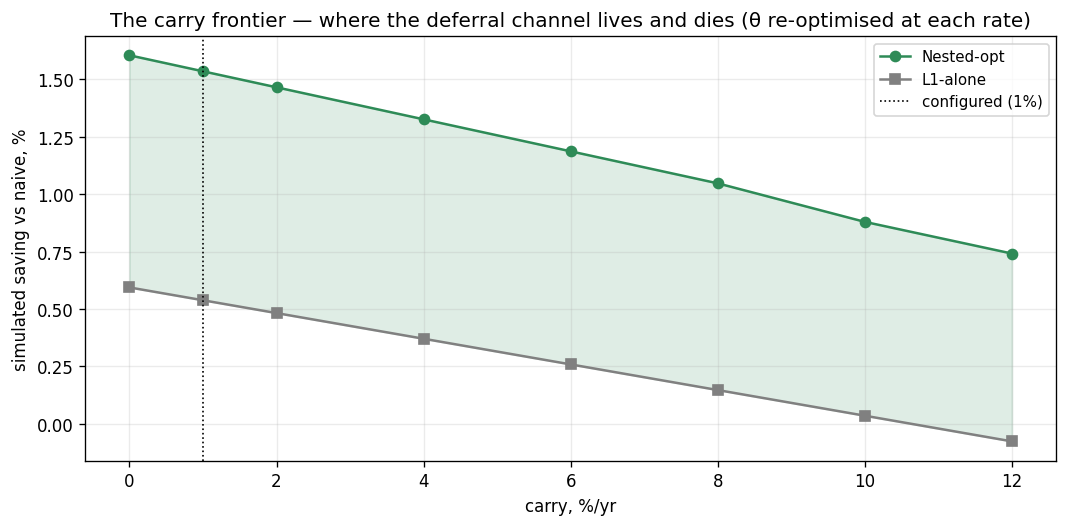

Saved: data/10_carry_frontier.png


In [9]:
# ── Carry frontier (re-optimised per carry) + I_MAX sensitivity ─────────────
frontier = []
for c in CARRY_SWEEP:
    _, w_c = nested_walkforward_v2(frames['STRICT'], DEF_AMPS, arm='opt',
                                   carry=c, i_max=I_MAX)
    sv_o = procurement_sim(w_c, frames['STRICT']['settle'], c, I_MAX)
    sv_l = procurement_sim(w_paths[('STRICT', 'L1-alone')],
                           frames['STRICT']['settle'], c, I_MAX)
    frontier.append({'carry': c, 'opt': sv_o, 'l1': sv_l, 'edge': sv_o - sv_l})
    print(f'  carry {c:5.1%}: opt {sv_o:+.2f}% | L1 {sv_l:+.2f}% | edge {sv_o - sv_l:+.2f}pp')
fr = pd.DataFrame(frontier).set_index('carry')
prefix_alive = []
for c in fr.index:
    if fr.loc[c, 'edge'] >= 0:
        prefix_alive.append(c)
    else:
        break
if prefix_alive:
    print(f'\nCarry frontier: deferral edge ≥ 0 from 0 up to '
          f'{max(prefix_alive):.0%}/yr (contiguous from zero).')
else:
    print(f'\nCarry frontier: no edge even at zero carry '
          f'(edge at configured {CARRY_ANNUAL:.0%} = '
          f'{fr.loc[CARRY_ANNUAL, "edge"] if CARRY_ANNUAL in fr.index else float("nan"):+.2f} pp). '
          f'Any isolated positive cells at high carry are optimiser-posture artifacts, '
          f'not deferral value.')

imax_rows = []
for im in IMAX_SWEEP:
    _, w_im = nested_walkforward_v2(frames['STRICT'], DEF_AMPS, arm='opt',
                                    carry=CARRY_ANNUAL, i_max=im)
    sv_o = procurement_sim(w_im, frames['STRICT']['settle'], CARRY_ANNUAL, im)
    sv_l = procurement_sim(w_paths[('STRICT', 'L1-alone')],
                           frames['STRICT']['settle'], CARRY_ANNUAL, im)
    imax_rows.append({'i_max': im, 'opt': sv_o, 'l1': sv_l, 'edge': sv_o - sv_l})
imx = pd.DataFrame(imax_rows).set_index('i_max')
print('\nStorage-cap sensitivity (at default carry):')
print(imx.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fr.index * 100, fr['opt'], marker='o', color='seagreen', label='Nested-opt')
ax.plot(fr.index * 100, fr['l1'], marker='s', color='gray', label='L1-alone')
ax.fill_between(fr.index * 100, fr['l1'], fr['opt'],
                where=fr['opt'] >= fr['l1'], alpha=0.15, color='seagreen')
ax.axvline(CARRY_ANNUAL * 100, color='black', ls=':', lw=1,
           label=f'configured ({CARRY_ANNUAL:.0%})')
ax.set_xlabel('carry, %/yr')
ax.set_ylabel('simulated saving vs naive, %')
ax.set_title('The carry frontier — where the deferral channel lives and dies '
             '(θ re-optimised at each rate)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('data/10_carry_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/10_carry_frontier.png')

In [10]:
# ── Live window + current reading with channel attribution ─────────────────
last_theta = results[('STRICT', 'Nested-opt')].iloc[-1]
theta_live = dict(lambda_d=float(last_theta['lambda_d']),
                  wts={a: int(last_theta[f'w_{a}']) for a in DEF_AMPS})
w_live, contrib = composite_w_v2(frames['STRICT'], theta_live['lambda_d'],
                                 theta_live['wts'], want_contrib=True)

live_span = w_live[w_live.index.year >= 2025].dropna()
if len(live_span) >= 12:
    sv_live_o = procurement_sim(live_span, frames['STRICT']['settle'],
                                CARRY_ANNUAL, I_MAX)
    w_l1_full = composite_w_v2(frames['STRICT'], 0.0, dict.fromkeys(DEF_AMPS, 0))
    sv_live_l = procurement_sim(w_l1_full.reindex(live_span.index),
                                frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX)
    print(f'Live window {live_span.index[0].date()} → {live_span.index[-1].date()} '
          f'({len(live_span)} months, partial): opt {sv_live_o:+.2f}% vs '
          f'L1 {sv_live_l:+.2f}% [indicative only]')

hist = procurement_sim(w_live, frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX,
                       detail=True)
t_last = w_live.dropna().index[-1]
row_c = contrib.loc[t_last]
f_last = frames['STRICT'].loc[t_last]
print(f'\n═══ Current reading — {t_last.date()} (final-θ view) ═══')
print(f'  desired w = {w_live.loc[t_last]:.2f}  →  {zone_of(w_live.loc[t_last])}')
print(f'  level channel:  L1 buy = {f_last["l1_buy"]:.2f} → {row_c["level_L1"]:+.2f}')
name_map = {'stu': 'stocks-to-use', 'enso': 'ENSO', 'flow': 'flowering drought'}
for a in DEF_AMPS:
    col = f'defer_{a}'
    if col in row_c.index and theta_live['wts'].get(a, 0) > 0:
        print(f'  deferral · {name_map[a]:18s} c = {f_last[f"c_{a}"]:+.2f} '
              f'→ {row_c[col]:+.2f}')
i_now = hist['inventory'].iloc[-1]
p_now = hist['p_buy'].iloc[-1]
print(f'  inventory position: {i_now:.2f} months of cover (cap {I_MAX:.0f}); '
      f'feasible purchase this month {p_now:.2f}×'
      + ('  [desire clipped by storage]' if abs(p_now - w_live.loc[t_last]) > 1e-9 else ''))

Live window 2025-01-31 → 2026-05-31 (17 months, partial): opt +0.99% vs L1 +2.62% [indicative only]

═══ Current reading — 2026-05-31 (final-θ view) ═══
  desired w = 1.75  →  STRONG BUY
  level channel:  L1 buy = 0.79 → +0.43
  deferral · flowering drought  c = +1.00 → +0.60
  inventory position: 3.00 months of cover (cap 3); feasible purchase this month 1.13×  [desire clipped by storage]


## 7. Ablations — Leave-One-Amplifier-Out

Full nested walk-forward re-run without each deferral amplifier; Δ is (full − without),
positive = the amplifier earned OOS simulated value. 06's warning stands: the optimiser's
training favourite is not necessarily an OOS contributor — this table is the arbiter.

In [11]:
abl_rows = []
for a in DEF_AMPS:
    sub = [x for x in DEF_AMPS if x != a]
    _, w_a = nested_walkforward_v2(frames['STRICT'], sub, arm='opt')
    sv_a = procurement_sim(w_a, frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX)
    abl_rows.append({'removed': a, 'sim_saving': sv_a,
                     'delta_vs_full': s_opt['saving'] - sv_a})
abl = pd.DataFrame(abl_rows).set_index('removed')
print(f'Full basket: {s_opt["saving"]:+.2f}%\n')
print(abl.round(2).to_string())

Full basket: +1.53%

         sim_saving  delta_vs_full
removed                           
stu            1.53           0.00
enso           1.68          -0.14
flow           1.52           0.02


## 8. Robusta Twin

Two-channel on WB robusta with the honest basket ({stu, enso}; Minas flowering and the
Vietnam monsoon gap as documented in 06 §9). Gates D1/D2 at the configured parameters; the
carry frontier is arabica-only to keep this section lean — robusta inherits the machinery,
rerun the §6 sweep with `frames_rob` if its frontier is ever needed.

In [12]:
AMPS_ROB = ['stu', 'enso']
frames_rob = build_components(raw['wb_rob'], True, AMPS_ROB)

res_r_l1, w_r_l1 = nested_walkforward_v2(frames_rob, AMPS_ROB, arm='l1')
res_r_opt, w_r_opt = nested_walkforward_v2(frames_rob, AMPS_ROB, arm='opt')
sim_r_l1 = procurement_sim(w_r_l1, frames_rob['settle'], CARRY_ANNUAL, I_MAX, detail=True)
sim_r_opt = procurement_sim(w_r_opt, frames_rob['settle'], CARRY_ANNUAL, I_MAX, detail=True)

rt = pd.DataFrame({'L1-alone': pd.Series(sim_r_l1['per_year']),
                   'Nested-opt': pd.Series(sim_r_opt['per_year'])})
print('Robusta twin — per-year simulated saving (STRICT):')
print(pd.concat([rt, rt.min().rename('WORST').to_frame().T]).round(2).to_string())
print(f"\nHeadline: opt {sim_r_opt['saving']:+.2f}%  vs  L1 {sim_r_l1['saving']:+.2f}%")

D1r = sim_r_opt['saving'] >= sim_r_l1['saving']
gap_r = (pd.Series(sim_r_opt['per_year']) - pd.Series(sim_r_l1['per_year'])).dropna()
D2r = gap_r.min() >= -1.0
print(f'Gates: D1 {"PASS" if D1r else "FAIL"} | D2 {"PASS" if D2r else "FAIL"} '
      f'(worst gap {gap_r.min():+.2f} pp)')

last_r = res_r_opt.iloc[-1]
theta_r = dict(lambda_d=float(last_r['lambda_d']),
               wts={a: int(last_r[f'w_{a}']) for a in AMPS_ROB})
w_r_live = composite_w_v2(frames_rob, theta_r['lambda_d'], theta_r['wts'], amps=AMPS_ROB)
lr = w_r_live.dropna()
if len(lr):
    print(f'Latest robusta reading ({lr.index[-1].date()}, last-θ applied): '
          f'w = {lr.iloc[-1]:.2f} → {zone_of(lr.iloc[-1])}')

Robusta twin — per-year simulated saving (STRICT):
       L1-alone  Nested-opt
2013      -1.98       -2.06
2014       2.26        2.22
2015       1.48        2.56
2016       3.00        3.57
2017       1.92        2.01
2018      -1.43       -1.79
2019      -0.86       -0.86
2020      -0.33       -0.34
2021      -4.42       -4.22
2022       2.40        2.40
2023      -4.48       -2.95
2024      -6.32       -6.32
WORST     -6.32       -6.32

Headline: opt -1.00%  vs  L1 -1.26%
Gates: D1 PASS | D2 PASS (worst gap -0.36 pp)
Latest robusta reading (2025-12-31, last-θ applied): w = 1.75 → STRONG BUY


## 9. Save Reference Outputs

The stitched OOS desired weights, the **feasible** purchase path and inventory (what a
downstream consumer should actually execute against), and the θ path.

In [13]:
out = frames['STRICT'].copy()
out['w_oos'] = w_paths[('STRICT', 'Nested-opt')]
out['w_l1_oos'] = w_paths[('STRICT', 'L1-alone')]
out['p_buy_oos'] = s_opt['p_buy']
out['inventory_oos'] = s_opt['inventory']
out['w_live_theta'] = w_live
out['zone'] = out['w_oos'].map(lambda v: zone_of(v) if pd.notna(v) else np.nan)
out.to_csv('data/10_composite_v2_monthly.csv')

out_r = frames_rob.copy()
out_r['w_oos'] = w_r_opt
out_r.to_csv('data/10_composite_v2_robusta.csv')

results[('STRICT', 'Nested-opt')].to_csv('data/10_theta_path.csv')
print('Saved: data/10_composite_v2_monthly.csv, data/10_composite_v2_robusta.csv,')
print('       data/10_theta_path.csv')

Saved: data/10_composite_v2_monthly.csv, data/10_composite_v2_robusta.csv,
       data/10_theta_path.csv


## 10. Summary & Limitations

Read the verdict from §6's gate block and the carry frontier — this cell is interpretation
discipline.

**For the deferral channel to be trusted:** D1–D3 pass at your parameters, the frontier
shows headroom above your actual carry (an edge that dies at 2%/yr when you pay 1.5% is not
a production margin), the θ-path is stable or converging rather than wandering, and the §7
ablations attribute the edge to amplifiers whose independence was already established
(NB05/NB06 partials). If D1 fails here too, the question is closed with unusual finality:
the amplifiers' directional information (real — 06 measured it) is not extractable as
procurement value under level accounting (06) **or** physical deferral accounting (this
notebook), and L1-alone is the suite's final answer at production.

**Limitations, inherited and new:** n_eff ≈ 7 independent cycles — signs are honest,
magnitudes have wide bars. The simulation abstracts lot sizing, transaction costs, market
impact, and differential/basis risk between KC futures and physical green coffee. The naive
baseline's buffer policy (I0) leaks a small carry-difference term bounded by
CARRY·I_MAX/12 per month — it cancels to first order in every D-gate (both arms share the
freedom) but colours the vs-naive headline at high carry. USDA PSD vintage look-ahead and
the KC=F splice are inherited and disclosed in 04/01. And the carry number itself is the
softest input in the notebook: gates were evaluated at the configured rate — if treasury
prices inventory differently than `CARRY_ANNUAL`, re-run §6 before believing anything.

# 11 — Continuation: strength, concentration, and robustness

This continuation leaves the original analysis unchanged and adds diagnostics aimed at the main unresolved question: **is the nested-opt edge broad and repeatable, or concentrated in one regime/end point?**

Run the notebook from the top. The additions below use the original notebook's objects (`frames`, `w_paths`, `sims`, `results`, and the simulator functions) and add:

1. exact value decomposition and leave-one-year-out influence;
2. endpoint sensitivity and paired year-block inference;
3. a full nested-walk-forward timing placebo;
4. re-optimised sensitivity to carry accounting, terminal marks, and execution friction;
5. a causal-centering check for the one-sided flowering feature;
6. a corrected live inventory state that stitches the actual OOS path into the post-2024 live path.

None of these checks is designed to manufacture a stronger result. They distinguish a genuinely persistent effect from a lucky terminal regime or modelling convention.

In [14]:
# ── 11.1 Quick audit of the saved result and selected θ path ─────────────────
strict_l1 = pd.Series(sims[('STRICT', 'L1-alone')]['per_year'], name='l1_pct')
strict_opt = pd.Series(sims[('STRICT', 'Nested-opt')]['per_year'], name='opt_pct')
year_gap_pct = pd.concat([strict_l1, strict_opt], axis=1)
year_gap_pct['gap_pp'] = year_gap_pct['opt_pct'] - year_gap_pct['l1_pct']
year_gap_pct['sign'] = np.select(
    [year_gap_pct['gap_pp'] > 1e-12, year_gap_pct['gap_pp'] < -1e-12],
    ['positive', 'negative'], default='zero')

print('STRICT annual paired gaps (Nested-opt − L1-alone):')
print(year_gap_pct.round(2).to_string())
print('\nCounts:', year_gap_pct['sign'].value_counts().to_dict())
print(f"Headline edge: {s_opt['saving'] - s_l1['saving']:+.3f} pp")

res_theta = results[('STRICT', 'Nested-opt')].copy()
res_theta['active_amp'] = 'abstain'
for y, row in res_theta.iterrows():
    active = [a for a in DEF_AMPS if row.get(f'w_{a}', 0) > 0]
    if active:
        # Show the dominant active amplifier; ties are printed as a '+' combination.
        mx = max(row[f'w_{a}'] for a in active)
        res_theta.loc[y, 'active_amp'] = '+'.join(
            a for a in active if row[f'w_{a}'] == mx)
res_theta['at_lambda_boundary'] = np.isclose(res_theta['lambda_d'], max(GRID_LAMBDA_D))

print('\nChosen θ path:')
print(res_theta[['lambda_d', 'active_amp', 'at_lambda_boundary']].to_string())
print(f"\nλ_D is at the top of the tested grid in "
      f"{res_theta['at_lambda_boundary'].mean():.0%} of OOS years.")
print('A boundary-hugging optimum is a warning: the grid found a direction, not necessarily a stable magnitude.')

STRICT annual paired gaps (Nested-opt − L1-alone):
      l1_pct  opt_pct  gap_pp      sign
2013   -3.54    -3.58   -0.03  negative
2014    6.45     6.29   -0.16  negative
2015    3.62     2.97   -0.64  negative
2016    1.48     0.83   -0.65  negative
2017   -0.27     0.03    0.30  positive
2018   -2.84    -2.84    0.00      zero
2019    2.87     3.10    0.22  positive
2020    2.94     2.03   -0.91  negative
2021   -6.94    -7.03   -0.09  negative
2022    3.41     3.41    0.00      zero
2023    1.79     1.79    0.00      zero
2024   -2.20     6.47    8.67  positive

Counts: {'negative': 6, 'positive': 3, 'zero': 3}
Headline edge: +0.997 pp

Chosen θ path:
      lambda_d active_amp  at_lambda_boundary
year                                         
2013       0.6       enso                True
2014       0.6       enso                True
2015       0.6       enso                True
2016       0.6       enso                True
2017       0.6       enso                True
2018       0.6 

## 11.2 Exact economic ledger and year influence

The original per-year percentages are useful but cannot be added directly because every year has a different price denominator. The helper below reconstructs each policy's purchase cash, carry, execution friction, and inventory mark in **cash units**, then produces an annual decomposition that telescopes exactly to the total result.

This lets us answer three questions without approximation:

- how much of the total opt-vs-L1 edge came from each year;
- what the headline would have been after deleting any one test year;
- whether the result depends on the final mark-to-market date.

Exact annual opt-vs-L1 incremental value:
       naive_cost    opt_gain     l1_gain  incremental_value  incremental_pp  share_of_total_edge
year                                                                                             
2013  1479.499977  -52.907529  -52.413500              -0.49           -0.03                -0.00
2014  2161.850006  135.930491  139.419897              -3.49           -0.16                -0.02
2015  1556.599983   46.301183   56.294889              -9.99           -0.64                -0.05
2016  1635.299995   13.624880   24.257265             -10.63           -0.65                -0.05
2017  1587.050011    0.461602   -4.248679               4.71            0.30                 0.02
2018  1345.149994  -38.206435  -38.206435               0.00            0.00                 0.00
2019  1244.899994   38.542821   35.748264               2.79            0.22                 0.01
2020  1346.350006   27.382015   39.569851             -12.19           -0.91

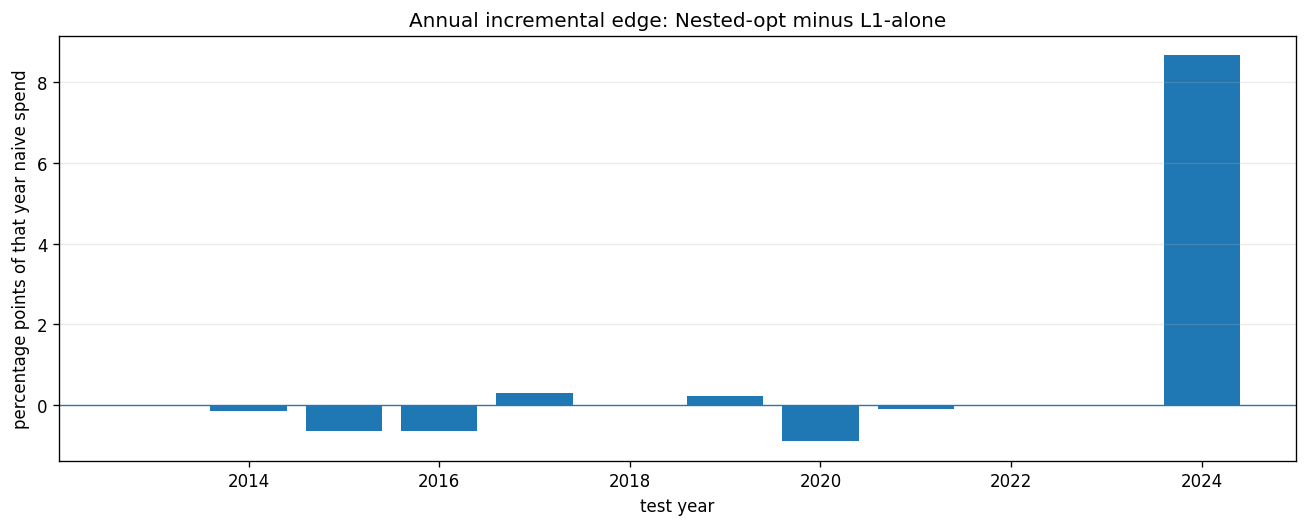

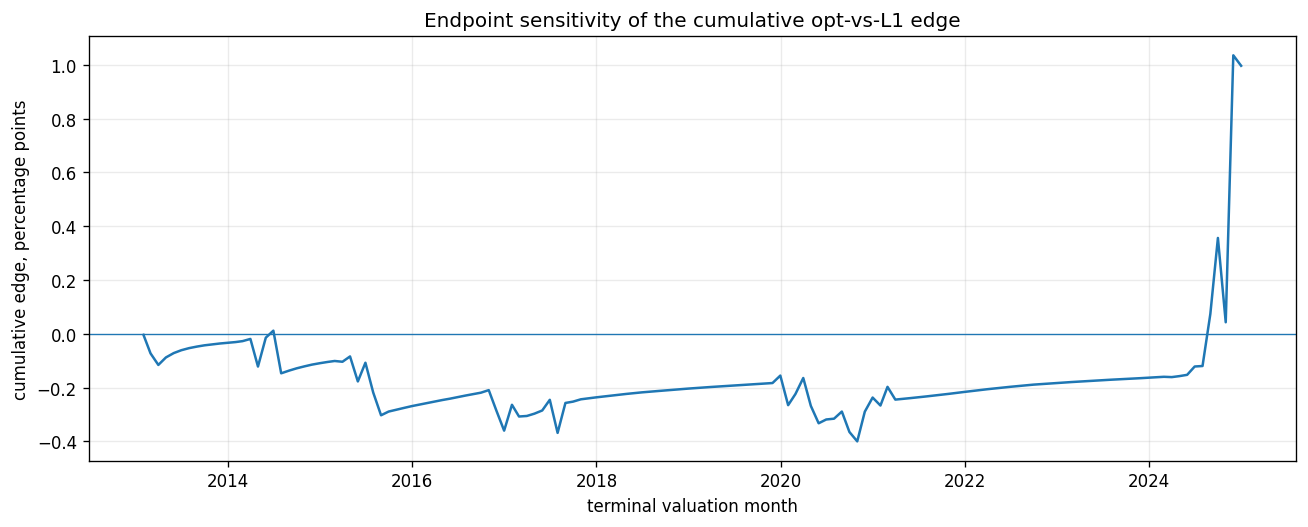

In [15]:
def procurement_ledger(w, settle, carry_annual=CARRY_ANNUAL, i_max=I_MAX, i0=None,
                       carry_mode='excess', terminal_haircut=1.0,
                       deviation_cost_bps=0.0):
    """Detailed procurement accounting under alternative economic conventions.

    Parameters
    ----------
    w : pd.Series
        Desired monthly purchase multiple.
    settle : pd.Series
        Monthly price series.
    carry_mode : {'excess', 'absolute', 'average_absolute'}
        'excess' reproduces the notebook: charge only inventory above i0; naive carry is 0.
        'absolute' charges both policies on end-of-month inventory.
        'average_absolute' charges both policies on average start/end inventory.
    terminal_haircut : float in [0, 1]
        Fraction of excess terminal inventory marked at the last observed price.
    deviation_cost_bps : float >= 0
        Conservative execution/handling cost on |purchase - 1| × price.

    Returns a dict with monthly and annual ledgers plus total saving vs naive.
    """
    if i0 is None:
        i0 = i_max / 2.0
    if carry_mode not in {'excess', 'absolute', 'average_absolute'}:
        raise ValueError("carry_mode must be 'excess', 'absolute', or 'average_absolute'")
    if not (0.0 <= terminal_haircut <= 1.0):
        raise ValueError('terminal_haircut must lie in [0, 1]')
    if deviation_cost_bps < 0:
        raise ValueError('deviation_cost_bps must be non-negative')

    s = pd.concat([w.rename('w'), settle.rename('price')], axis=1).dropna()
    if len(s) < 12:
        raise ValueError('Need at least 12 overlapping monthly observations')

    wv = s['w'].to_numpy(float)
    pv = s['price'].to_numpy(float)
    n = len(s)
    mc = carry_annual / 12.0

    p_buy = np.empty(n)
    inv_start = np.empty(n)
    inv_end = np.empty(n)
    clipped = np.zeros(n, dtype=bool)
    prev = float(i0)
    for k in range(n):
        inv_start[k] = prev
        lo = max(0.0, 1.0 - prev)
        hi = 1.0 + i_max - prev
        p_buy[k] = min(max(wv[k], lo), hi)
        clipped[k] = not np.isclose(p_buy[k], wv[k])
        prev = prev + p_buy[k] - 1.0
        inv_end[k] = prev

    if carry_mode == 'excess':
        carry_units = np.maximum(inv_end - i0, 0.0)
        naive_carry_units = np.zeros(n)
    elif carry_mode == 'absolute':
        carry_units = inv_end
        naive_carry_units = np.full(n, i0)
    else:  # average_absolute
        carry_units = 0.5 * (inv_start + inv_end)
        naive_carry_units = np.full(n, i0)

    purchase_cash = p_buy * pv
    carry_cash = mc * carry_units * pv
    deviation_cash = (deviation_cost_bps / 10_000.0) * np.abs(p_buy - 1.0) * pv
    naive_purchase_cash = pv
    naive_carry_cash = mc * naive_carry_units * pv

    monthly = pd.DataFrame({
        'w_desired': wv,
        'price': pv,
        'p_buy': p_buy,
        'inventory_start': inv_start,
        'inventory_end': inv_end,
        'purchase_cash': purchase_cash,
        'carry_cash': carry_cash,
        'deviation_cash': deviation_cash,
        'policy_cash': purchase_cash + carry_cash + deviation_cash,
        'naive_cash': naive_purchase_cash + naive_carry_cash,
        'clipped': clipped,
    }, index=s.index)

    terminal_mark = terminal_haircut * (inv_end[-1] - i0) * pv[-1]
    total_policy = monthly['policy_cash'].sum() - terminal_mark
    total_naive = monthly['naive_cash'].sum()
    saving = (total_naive - total_policy) / total_naive * 100.0

    # Annual economic gains telescope exactly. Intermediate year-end marks are full
    # marks; only the final sample endpoint receives terminal_haircut.
    years = np.sort(monthly.index.year.unique())
    annual_rows = []
    previous_close_mark = 0.0
    for j, y in enumerate(years):
        m = monthly.index.year == y
        last_row = monthly.loc[m].iloc[-1]
        factor = terminal_haircut if j == len(years) - 1 else 1.0
        close_mark = factor * (last_row['inventory_end'] - i0) * last_row['price']
        naive_cost_y = monthly.loc[m, 'naive_cash'].sum()
        policy_cash_y = monthly.loc[m, 'policy_cash'].sum()
        economic_gain_y = naive_cost_y - policy_cash_y + close_mark - previous_close_mark
        annual_rows.append({
            'year': int(y),
            'naive_cost': float(naive_cost_y),
            'policy_cash': float(policy_cash_y),
            'open_mark': float(previous_close_mark),
            'close_mark': float(close_mark),
            'economic_gain': float(economic_gain_y),
            'saving_pct': float(economic_gain_y / naive_cost_y * 100.0),
        })
        previous_close_mark = close_mark

    annual = pd.DataFrame(annual_rows).set_index('year')
    # Exact accounting identity.
    assert np.isclose(annual['economic_gain'].sum(), total_naive - total_policy, atol=1e-7)

    return {
        'saving': float(saving),
        'monthly': monthly,
        'annual': annual,
        'terminal_mark': float(terminal_mark),
        'clip_share': float(clipped.mean()),
        'span': (monthly.index[0], monthly.index[-1]),
    }


led_opt = procurement_ledger(w_paths[('STRICT', 'Nested-opt')], frames['STRICT']['settle'])
led_l1 = procurement_ledger(w_paths[('STRICT', 'L1-alone')], frames['STRICT']['settle'])

# Reproduce the original headline before using the richer ledger.
assert np.isclose(led_opt['saving'], s_opt['saving'], atol=1e-10)
assert np.isclose(led_l1['saving'], s_l1['saving'], atol=1e-10)

annual_pair = pd.DataFrame({
    'naive_cost': led_opt['annual']['naive_cost'],
    'opt_gain': led_opt['annual']['economic_gain'],
    'l1_gain': led_l1['annual']['economic_gain'],
})
annual_pair['incremental_value'] = annual_pair['opt_gain'] - annual_pair['l1_gain']
annual_pair['incremental_pp'] = annual_pair['incremental_value'] / annual_pair['naive_cost'] * 100.0
annual_pair['share_of_total_edge'] = (
    annual_pair['incremental_value'] / annual_pair['incremental_value'].sum())

full_edge = annual_pair['incremental_value'].sum() / annual_pair['naive_cost'].sum() * 100.0
assert np.isclose(full_edge, s_opt['saving'] - s_l1['saving'], atol=1e-10)

influence = []
for y in annual_pair.index:
    keep = annual_pair.index != y
    edge_without_y = (annual_pair.loc[keep, 'incremental_value'].sum()
                      / annual_pair.loc[keep, 'naive_cost'].sum() * 100.0)
    influence.append({'removed_year': y, 'edge_without_year_pp': edge_without_y,
                      'change_from_full_pp': edge_without_y - full_edge})
influence = pd.DataFrame(influence).set_index('removed_year')

print('Exact annual opt-vs-L1 incremental value:')
print(annual_pair.round({'incremental_value': 2, 'incremental_pp': 2,
                         'share_of_total_edge': 2}).to_string())
print(f'\nExact full edge: {full_edge:+.3f} pp')
print('\nLeave-one-test-year-out edge:')
print(influence.round(3).to_string())

# Endpoint sensitivity: use the already-generated causal inventory paths. Future data do
# not affect the path up to a given endpoint, so cumulative cash + that endpoint's mark is exact.
mo = led_opt['monthly']
ml = led_l1['monthly']
common = mo.index.intersection(ml.index)
mo, ml = mo.loc[common], ml.loc[common]
naive_cum = mo['naive_cash'].cumsum()
opt_cash_cum = mo['policy_cash'].cumsum()
l1_cash_cum = ml['policy_cash'].cumsum()
opt_mark = (mo['inventory_end'] - I0) * mo['price']
l1_mark = (ml['inventory_end'] - I0) * ml['price']
endpoint_edge = ((l1_cash_cum - opt_cash_cum + opt_mark - l1_mark)
                 / naive_cum * 100.0).rename('edge_pp')

print('\nEdge at each calendar year-end:')
print(endpoint_edge[endpoint_edge.index.month == 12].round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(annual_pair.index, annual_pair['incremental_pp'])
ax.axhline(0, lw=0.8)
ax.set_title('Annual incremental edge: Nested-opt minus L1-alone')
ax.set_ylabel('percentage points of that year naive spend')
ax.set_xlabel('test year')
ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(endpoint_edge.index, endpoint_edge.values, lw=1.5)
ax.axhline(0, lw=0.8)
ax.set_title('Endpoint sensitivity of the cumulative opt-vs-L1 edge')
ax.set_ylabel('cumulative edge, percentage points')
ax.set_xlabel('terminal valuation month')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 11.3 Paired inference at the year-block level

Monthly observations are strongly autocorrelated and are not independent trials. Treating all months as independent would produce meaningless confidence intervals. The smallest defensible resampling unit here is a calendar year, and even years are not fully independent because coffee cycles and inventory positions cross boundaries.

The cell below therefore reports several deliberately conservative diagnostics:

- an **exact paired sign-flip test** over annual economic-value differences;
- a sign test and Wilcoxon signed-rank test on annual paired gaps;
- a circular moving-block bootstrap over years, preserving short runs of adjacent regimes;
- the bootstrap probability that the weighted edge is positive.

With only 12 OOS years, these are uncertainty diagnostics, not a magic certification.

Observed weighted edge: +0.997 pp
Exact paired sign-flip p-value (two-sided): 0.9297
Sign test: 3/9 non-zero years positive, p=0.5078
Wilcoxon signed-rank p-value: 0.6523
20,000-draw circular 3-year-block bootstrap:
  median +0.977 pp | 95% interval [-0.309, +2.889] pp
  P(edge > 0) = 0.693


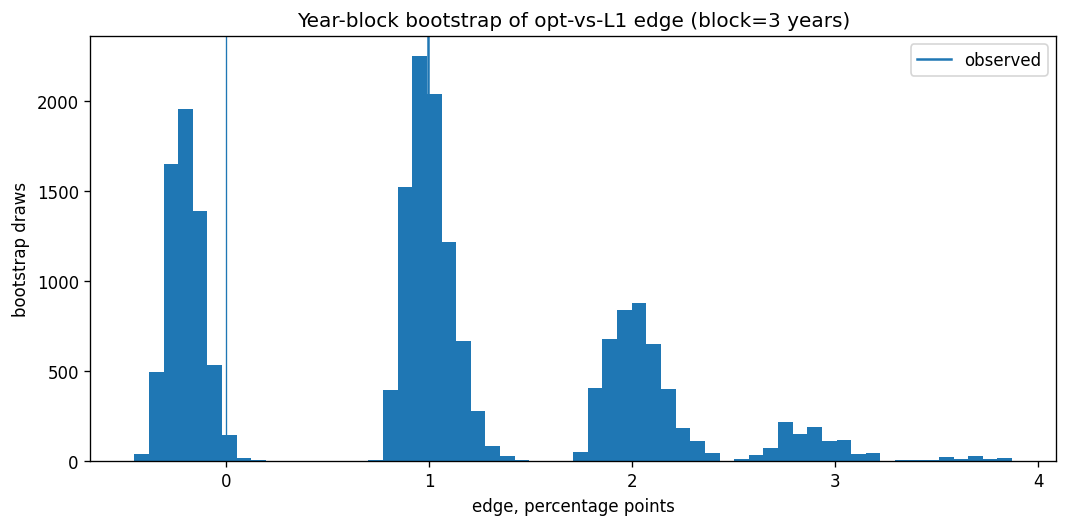

In [16]:
from itertools import product

vals = annual_pair['incremental_value'].to_numpy(float)
den = annual_pair['naive_cost'].to_numpy(float)
gaps_pp = annual_pair['incremental_pp'].to_numpy(float)
n_years = len(vals)

# Exact two-sided paired sign-flip test using the same weighted total-value statistic
# as the headline. Under the sharp null, each year's opt-vs-L1 value can change sign.
observed_abs_value = abs(vals.sum())
null_abs_values = np.fromiter(
    (abs(np.dot(np.asarray(signs, dtype=float), vals))
     for signs in product((-1.0, 1.0), repeat=n_years)),
    dtype=float,
    count=2 ** n_years,
)
p_exact = np.mean(null_abs_values >= observed_abs_value - 1e-12)

nonzero = gaps_pp[~np.isclose(gaps_pp, 0.0)]
n_pos = int((nonzero > 0).sum())
sign_test = stats.binomtest(n_pos, len(nonzero), 0.5, alternative='two-sided')
try:
    wilcoxon = stats.wilcoxon(nonzero, alternative='two-sided', zero_method='wilcox')
    wilcoxon_p = float(wilcoxon.pvalue)
except ValueError:
    wilcoxon_p = np.nan

# Circular moving-block bootstrap of adjacent years.
BOOT_REPS = 20_000
BLOCK_YEARS = 3
rng_boot = np.random.default_rng(20260802)
boot_edges = np.empty(BOOT_REPS)
for b in range(BOOT_REPS):
    sample_idx = []
    while len(sample_idx) < n_years:
        start = int(rng_boot.integers(0, n_years))
        sample_idx.extend((start + k) % n_years for k in range(BLOCK_YEARS))
    sample_idx = np.asarray(sample_idx[:n_years], dtype=int)
    boot_edges[b] = vals[sample_idx].sum() / den[sample_idx].sum() * 100.0

ci_lo, ci_mid, ci_hi = np.percentile(boot_edges, [2.5, 50, 97.5])
prob_positive = float(np.mean(boot_edges > 0))

print(f'Observed weighted edge: {full_edge:+.3f} pp')
print(f'Exact paired sign-flip p-value (two-sided): {p_exact:.4f}')
print(f'Sign test: {n_pos}/{len(nonzero)} non-zero years positive, p={sign_test.pvalue:.4f}')
print(f'Wilcoxon signed-rank p-value: {wilcoxon_p:.4f}')
print(f'{BOOT_REPS:,}-draw circular {BLOCK_YEARS}-year-block bootstrap:')
print(f'  median {ci_mid:+.3f} pp | 95% interval [{ci_lo:+.3f}, {ci_hi:+.3f}] pp')
print(f'  P(edge > 0) = {prob_positive:.3f}')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(boot_edges, bins=60)
ax.axvline(full_edge, lw=1.5, label='observed')
ax.axvline(0, lw=0.8)
ax.set_title(f'Year-block bootstrap of opt-vs-L1 edge (block={BLOCK_YEARS} years)')
ax.set_xlabel('edge, percentage points')
ax.set_ylabel('bootstrap draws')
ax.legend()
plt.tight_layout()
plt.show()

## 11.4 Full-pipeline timing placebo

A normal backtest can look good merely because a persistent, autocorrelated feature happened to line up with one large price episode. The strongest practical null test here is to preserve each feature's marginal distribution, autocorrelation, and missing-data pattern, but **destroy its calendar alignment with price**.

For each placebo draw, every deferral component is circularly shifted by an independently sampled whole number of years within its valid observations. The entire nested walk-forward optimiser is then rerun. This correctly includes the optimiser's data-mining ability in the null distribution.

The empirical one-sided p-value asks: *how often can equally persistent but mistimed features produce an OOS edge at least as large as the observed one?*

`N_PLACEBO = 100` is a useful first pass. Raise it to 500–1,000 for a final result; runtime grows roughly linearly.

completed   10/100 placebo reruns


completed   20/100 placebo reruns


completed   30/100 placebo reruns


completed   40/100 placebo reruns


completed   50/100 placebo reruns


completed   60/100 placebo reruns


completed   70/100 placebo reruns


completed   80/100 placebo reruns


completed   90/100 placebo reruns


completed  100/100 placebo reruns

Observed edge: +0.997 pp
Placebo median: +0.074 pp
Placebo 95th percentile: +1.001 pp
Empirical one-sided p-value: 0.0693
Interpretation: a large p-value means the optimiser can often manufacture a similar edge from mistimed signals.
Saved: data/10_placebo_timing_results.csv


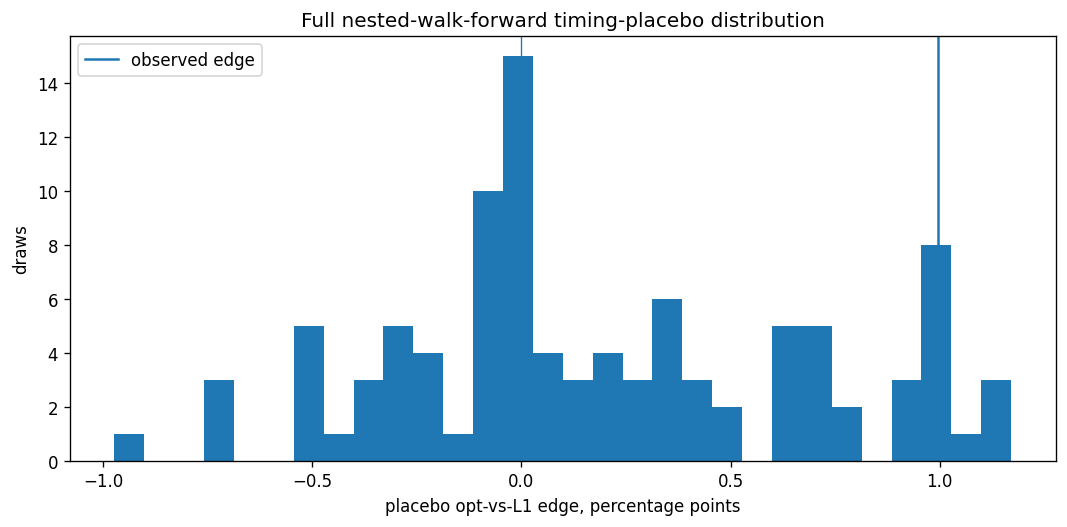

In [17]:
def circular_shift_valid_years(s, shift_years):
    """Rotate observed values by whole years while preserving the original NaN mask."""
    out = s.copy()
    mask = s.notna()
    values = s.loc[mask].to_numpy(copy=True)
    if len(values) == 0:
        return out
    shift_months = int(12 * shift_years) % len(values)
    out.loc[mask] = np.roll(values, shift_months)
    return out


def placebo_component_frame(df, amps, rng):
    """Independently mistime each component; preserve prices, L1, and availability masks."""
    out = df.copy()
    chosen = {}
    for a in amps:
        col = f'c_{a}'
        n_valid_years = max(1, int(df[col].notna().sum() // 12))
        # Avoid zero/near-zero shifts. For short features, use every non-zero feasible shift.
        max_shift = max(2, n_valid_years - 2)
        candidates = np.arange(2, max_shift + 1, dtype=int)
        if len(candidates) == 0:
            candidates = np.array([1], dtype=int)
        shift_y = int(rng.choice(candidates))
        out[col] = circular_shift_valid_years(df[col], shift_y)
        chosen[a] = shift_y
    return out, chosen


N_PLACEBO = 100
PLACEBO_SEED = 20260802
rng_placebo = np.random.default_rng(PLACEBO_SEED)
observed_edge = s_opt['saving'] - s_l1['saving']
placebo_rows = []

for b in range(N_PLACEBO):
    df_p, shifts = placebo_component_frame(frames['STRICT'], DEF_AMPS, rng_placebo)
    _, w_p = nested_walkforward_v2(df_p, DEF_AMPS, arm='opt')
    sv_p = procurement_sim(w_p, df_p['settle'], CARRY_ANNUAL, I_MAX)
    edge_p = sv_p - s_l1['saving']
    placebo_rows.append({'draw': b, 'edge_pp': edge_p,
                          **{f'shift_{a}_years': shifts[a] for a in DEF_AMPS}})
    if (b + 1) % 10 == 0:
        print(f'completed {b + 1:4d}/{N_PLACEBO} placebo reruns')

placebo = pd.DataFrame(placebo_rows).set_index('draw')
placebo_p = (1 + (placebo['edge_pp'] >= observed_edge - 1e-12).sum()) / (N_PLACEBO + 1)

print(f'\nObserved edge: {observed_edge:+.3f} pp')
print(f'Placebo median: {placebo["edge_pp"].median():+.3f} pp')
print(f'Placebo 95th percentile: {placebo["edge_pp"].quantile(0.95):+.3f} pp')
print(f'Empirical one-sided p-value: {placebo_p:.4f}')
print('Interpretation: a large p-value means the optimiser can often manufacture a similar edge from mistimed signals.')

placebo.to_csv('data/10_placebo_timing_results.csv')
print('Saved: data/10_placebo_timing_results.csv')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(placebo['edge_pp'], bins=30)
ax.axvline(observed_edge, lw=1.5, label='observed edge')
ax.axvline(0, lw=0.8)
ax.set_title('Full nested-walk-forward timing-placebo distribution')
ax.set_xlabel('placebo opt-vs-L1 edge, percentage points')
ax.set_ylabel('draws')
ax.legend()
plt.tight_layout()
plt.show()

## 11.5 Re-optimised economic-assumption sensitivity

The original simulator deliberately charges carry only on inventory above the shared baseline buffer and marks terminal excess inventory at 100% of the final spot price. Those are defensible choices, but they are choices.

The code below reruns the **entire outer walk-forward selection** under several alternatives rather than merely repricing the already-selected path:

- absolute carry paid by both strategy and naive baseline;
- carry on average monthly inventory rather than month-end inventory;
- 10–25 bps of conservative handling/execution cost on deviations from normal monthly buying;
- a 50% haircut on terminal excess inventory;
- a combined conservative case.

The opt-vs-L1 edge is the key column. A robust predictive relation should not reverse under modest, plausible conventions.

In [18]:
def score_theta_econ(df, theta, carry, i_max, amps, econ):
    w = composite_w_v2(df, theta['lambda_d'], theta['wts'], amps=amps)
    return procurement_ledger(
        w, df['settle'], carry_annual=carry, i_max=i_max,
        carry_mode=econ.get('carry_mode', 'excess'),
        terminal_haircut=econ.get('terminal_haircut', 1.0),
        deviation_cost_bps=econ.get('deviation_cost_bps', 0.0),
    )['saving']


def nested_walkforward_econ(df, amps, econ, arm='opt', carry=CARRY_ANNUAL,
                            i_max=I_MAX, test_years=WF_YEARS):
    """Original outer walk-forward, but train and evaluate under an economic variant."""
    rows, w_parts = [], []
    for y in test_years:
        train = df[(df.index >= CORE_START) & (df.index.year < y)]
        valid_years = [yy for yy in sorted(train.index.year.unique())
                       if train.loc[train.index.year == yy, 'l1_buy'].notna().sum() >= 10]
        if len(valid_years) < MIN_TRAIN_Y:
            continue

        if arm == 'l1':
            theta = dict(lambda_d=0.0, wts=dict.fromkeys(amps, 0))
        else:
            base_theta = dict(lambda_d=0.0, wts=dict.fromkeys(amps, 0))
            base = score_theta_econ(train, base_theta, carry, i_max, amps, econ)
            candidates = []
            for th in theta_grid_v2(amps):
                sv = score_theta_econ(train, th, carry, i_max, amps, econ)
                if not np.isfinite(sv):
                    continue
                if th['lambda_d'] > 0 and sv < base + OPT_MARGIN:
                    continue
                n_amps = sum(v > 0 for v in th['wts'].values())
                candidates.append(((-round(sv, 6), th['lambda_d'], n_amps), th))
            theta = min(candidates, key=lambda kv: kv[0])[1] if candidates else base_theta

        w_full = composite_w_v2(df, theta['lambda_d'], theta['wts'], amps=amps)
        rows.append({'year': y, 'lambda_d': theta['lambda_d'],
                     **{f'w_{a}': theta['wts'].get(a, 0) for a in amps}})
        w_parts.append(w_full[w_full.index.year == y])

    result = pd.DataFrame(rows).set_index('year')
    path = pd.concat(w_parts).sort_index() if w_parts else pd.Series(dtype=float)
    return result, path


econ_variants = {
    'original': dict(carry_mode='excess', terminal_haircut=1.0, deviation_cost_bps=0.0),
    'absolute carry': dict(carry_mode='absolute', terminal_haircut=1.0, deviation_cost_bps=0.0),
    'average absolute carry': dict(carry_mode='average_absolute', terminal_haircut=1.0,
                                   deviation_cost_bps=0.0),
    '10 bps deviation cost': dict(carry_mode='excess', terminal_haircut=1.0,
                                  deviation_cost_bps=10.0),
    '25 bps deviation cost': dict(carry_mode='excess', terminal_haircut=1.0,
                                  deviation_cost_bps=25.0),
    '50% terminal mark': dict(carry_mode='excess', terminal_haircut=0.5,
                              deviation_cost_bps=0.0),
    'combined conservative': dict(carry_mode='average_absolute', terminal_haircut=0.5,
                                  deviation_cost_bps=25.0),
}

sensitivity_rows = []
variant_paths = {}
variant_thetas = {}
for name, econ in econ_variants.items():
    theta_v, w_opt_v = nested_walkforward_econ(frames['STRICT'], DEF_AMPS, econ, arm='opt')
    _, w_l1_v = nested_walkforward_econ(frames['STRICT'], DEF_AMPS, econ, arm='l1')
    opt_v = procurement_ledger(w_opt_v, frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX,
                               **econ)['saving']
    l1_v = procurement_ledger(w_l1_v, frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX,
                              **econ)['saving']
    sensitivity_rows.append({'variant': name, 'opt_saving': opt_v, 'l1_saving': l1_v,
                             'edge_pp': opt_v - l1_v,
                             'lambda_boundary_share': np.isclose(
                                 theta_v['lambda_d'], max(GRID_LAMBDA_D)).mean()})
    variant_paths[name] = w_opt_v
    variant_thetas[name] = theta_v
    print(f'{name:24s}: opt {opt_v:+.3f}% | L1 {l1_v:+.3f}% | edge {opt_v-l1_v:+.3f} pp')

sensitivity = pd.DataFrame(sensitivity_rows).set_index('variant')
sensitivity.to_csv('data/10_economic_assumption_sensitivity.csv')
print('\nSensitivity table:')
print(sensitivity.round(3).to_string())
print('\nSaved: data/10_economic_assumption_sensitivity.csv')

original                : opt +1.535% | L1 +0.538% | edge +0.997 pp


absolute carry          : opt +1.572% | L1 +0.586% | edge +0.986 pp


average absolute carry  : opt +1.571% | L1 +0.585% | edge +0.987 pp


10 bps deviation cost   : opt +1.520% | L1 +0.522% | edge +0.998 pp


25 bps deviation cost   : opt +1.499% | L1 +0.498% | edge +1.001 pp


50% terminal mark       : opt +1.218% | L1 +1.629% | edge -0.411 pp


combined conservative   : opt +1.221% | L1 +1.635% | edge -0.414 pp

Sensitivity table:
                        opt_saving  l1_saving  edge_pp  lambda_boundary_share
variant                                                                      
original                     1.535      0.538    0.997                    1.0
absolute carry               1.572      0.586    0.986                    1.0
average absolute carry       1.571      0.585    0.987                    1.0
10 bps deviation cost        1.520      0.522    0.998                    1.0
25 bps deviation cost        1.499      0.498    1.001                    1.0
50% terminal mark            1.218      1.629   -0.411                    1.0
combined conservative        1.221      1.635   -0.414                    1.0

Saved: data/10_economic_assumption_sensitivity.csv


## 11.6 Causal centering of deferral components

`c_flow` is one-sided: it is zero in non-drought years and positive in drought years. That can be the correct economic shape, but it also means the feature has a positive mean and can change the strategy's average inventory posture rather than only its timing.

This robustness check transforms each deferral component using only information available before month *t*:

\[
\tilde c_t = \operatorname{clip}\left(\frac{c_t-\mu_{t-1}}{2\sigma_{t-1}}, -1, 1\right),
\]

where the expanding mean and standard deviation are shifted by one month. It then reruns the original nested optimisation. If the edge vanishes, the result depended on the components' unconditional levels; if it survives, the evidence is more consistent with time-varying information.

In [19]:
def causally_center_deferral(df, amps, min_history=24):
    out = df.copy()
    for a in amps:
        col = f'c_{a}'
        s = out[col].astype(float)
        past_mean = s.shift(1).expanding(min_periods=min_history).mean()
        past_std = s.shift(1).expanding(min_periods=min_history).std(ddof=0)
        z = (s - past_mean) / past_std.replace(0, np.nan)
        out[col] = (z / 2.0).clip(-1.0, 1.0)
    return out


frames_centered = causally_center_deferral(frames['STRICT'], DEF_AMPS, min_history=24)
res_centered, w_centered = nested_walkforward_v2(frames_centered, DEF_AMPS, arm='opt')
sv_centered = procurement_sim(w_centered, frames_centered['settle'], CARRY_ANNUAL, I_MAX)
centered_edge = sv_centered - s_l1['saving']

print(f'Raw nested-opt edge:      {s_opt["saving"] - s_l1["saving"]:+.3f} pp')
print(f'Causally centered edge:   {centered_edge:+.3f} pp')
print('\nCentered θ path:')
print(res_centered.to_string())
print(f"\nλ_D boundary share after centering: "
      f"{np.isclose(res_centered['lambda_d'], max(GRID_LAMBDA_D)).mean():.0%}")

# Component coverage after causal centering is intentionally later.
print('\nFirst valid centered component month:')
for a in DEF_AMPS:
    idx = frames_centered[f'c_{a}'].first_valid_index()
    print(f'  {a:5s}: {idx.date() if idx is not None else "—"}')

Raw nested-opt edge:      +0.997 pp
Causally centered edge:   +0.607 pp

Centered θ path:
      lambda_d  w_stu  w_enso  w_flow
year                                 
2013       0.6      0       1       0
2014       0.6      0       1       0
2015       0.6      0       1       0
2016       0.6      0       1       0
2017       0.6      0       1       0
2018       0.6      0       1       0
2019       0.6      0       1       0
2020       0.6      0       1       0
2021       0.6      0       1       0
2022       0.6      0       1       2
2023       0.6      0       1       2
2024       0.6      0       1       2

λ_D boundary share after centering: 100%

First valid centered component month:
  stu  : 2010-01-31
  enso : 2010-01-31
  flow : 2018-12-31


## 11.7 Correct live inventory state

The original current-reading cell calculates current inventory by applying the final 2024 θ retrospectively to the whole historical sample. That is a useful *counterfactual final-θ history*, but it is not the inventory a production implementation would actually hold.

The operational path below is stitched correctly:

- use the actual nested OOS desired weights through the last OOS month;
- freeze the final OOS θ only after that month;
- simulate once from the beginning of the OOS period so inventory carries into the live window.

This is the correct state for deciding the feasible current purchase.

In [20]:
# Final selected OOS θ, applied only after the OOS test span.
last_oos_month = w_paths[('STRICT', 'Nested-opt')].dropna().index.max()
post_oos_live = w_live[w_live.index > last_oos_month]
operational_w = pd.concat([
    w_paths[('STRICT', 'Nested-opt')].dropna(),
    post_oos_live.dropna(),
]).sort_index()
operational_w = operational_w[~operational_w.index.duplicated(keep='last')]

operational_sim = procurement_sim(
    operational_w, frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX, detail=True)

current_month = operational_sim['inventory'].index[-1]
current_desired = operational_w.loc[current_month]
current_feasible = operational_sim['p_buy'].loc[current_month]
current_inventory = operational_sim['inventory'].loc[current_month]

# Compare with the original final-θ-applied-to-all-history state.
counterfactual_hist = procurement_sim(
    w_live, frames['STRICT']['settle'], CARRY_ANNUAL, I_MAX, detail=True)
cf_inventory = counterfactual_hist['inventory'].loc[current_month]
cf_feasible = counterfactual_hist['p_buy'].loc[current_month]

print(f'Last OOS month: {last_oos_month.date()}')
print(f'Current operational month: {current_month.date()}')
print(f'  desired purchase: {current_desired:.3f}×  ({zone_of(current_desired)})')
print(f'  feasible purchase: {current_feasible:.3f}×')
print(f'  inventory after purchase: {current_inventory:.3f} months')
print('\nOriginal counterfactual final-θ history at the same month:')
print(f'  feasible purchase: {cf_feasible:.3f}×')
print(f'  inventory after purchase: {cf_inventory:.3f} months')
print(f'  state difference: {current_inventory - cf_inventory:+.3f} months')

op_out = pd.DataFrame({
    'w_operational': operational_w,
    'p_buy_operational': operational_sim['p_buy'],
    'inventory_operational': operational_sim['inventory'],
})
op_out.to_csv('data/10_operational_live_path_corrected.csv')
print('\nSaved: data/10_operational_live_path_corrected.csv')

Last OOS month: 2024-12-31
Current operational month: 2026-05-31
  desired purchase: 1.750×  (STRONG BUY)
  feasible purchase: 1.133×
  inventory after purchase: 3.000 months

Original counterfactual final-θ history at the same month:
  feasible purchase: 1.133×
  inventory after purchase: 3.000 months
  state difference: +0.000 months

Saved: data/10_operational_live_path_corrected.csv


## 11.8 Decision rules after running the continuation

Treat the original +0.99 pp opt-vs-L1 edge as **credible enough for production** only if most of the following are true:

- the edge remains positive after removing 2024 and across many terminal dates;
- the year-block interval is not dominated by zero or negative values;
- the timing-placebo p-value is small relative to a predeclared threshold;
- the edge survives reasonable carry, terminal-mark, and handling-cost conventions;
- causal centering does not erase the result;
- selected λ values stop hugging the top of the grid, or an expanded-grid test confirms a stable optimum;
- the corrected operational inventory path gives feasible actions that are materially different from L1 and operationally useful.

A failure is informative. It means the notebook has found a **regime-specific historical episode**, not yet a stable statistical relation. In that case, keep L1 as the production baseline and treat the deferral channel as a monitored research overlay until more genuinely independent cycles accumulate.